In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing_dataset.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
447,TA,TA,199900
6,Gd,TA,307000
1328,TA,Fa,256000
1448,NaN,Fa,112000
620,NaN,NaN,67000


# Categorical Data

**a. Mode Imputation (Most Frequent Value)**

Replace missing entries with the **most frequently occurring category** in that column.

-  Data is missing completely at random
- Simple, intuitive, works well when one category dominates and missingness is random.
- Downside: artificially inflates the frequency of the mode category, which can bias models that are sensitive to class balance.

In [3]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of Houses')

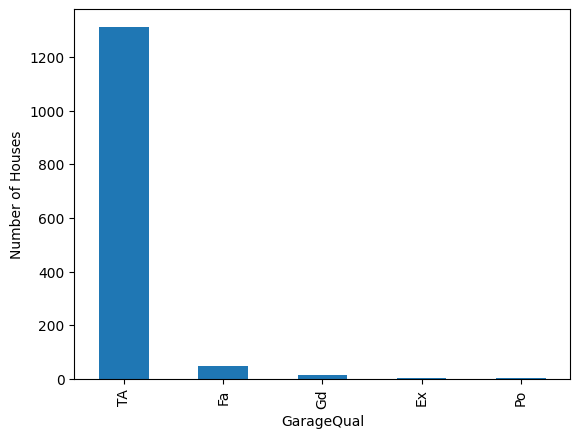

In [4]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')

In [5]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

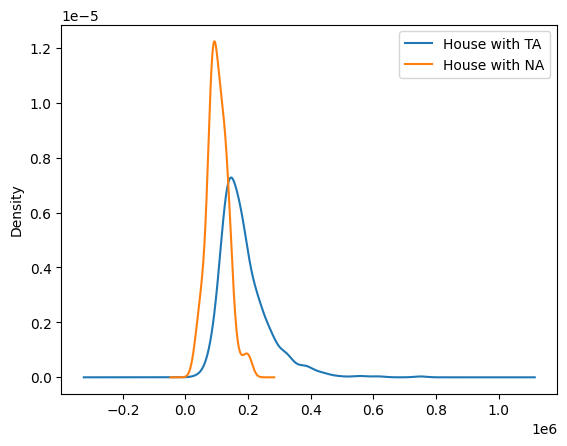

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

ax.legend(['House with TA', 'House with NA'], loc='best')

In [7]:
temp_df = df[df['GarageQual'] == 'TA']['SalePrice']

In [8]:
df.fillna({'GarageQual': 'TA'}, inplace=True)

<Axes: xlabel='GarageQual'>

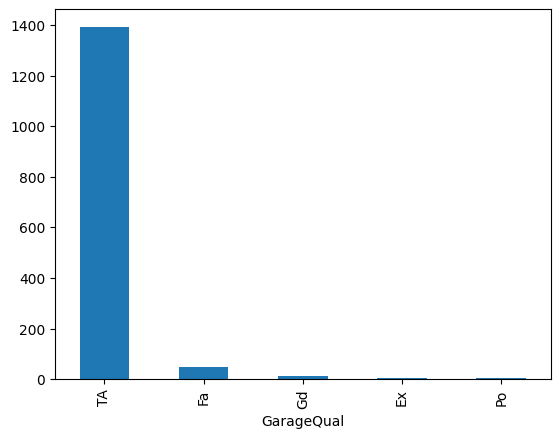

In [9]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()

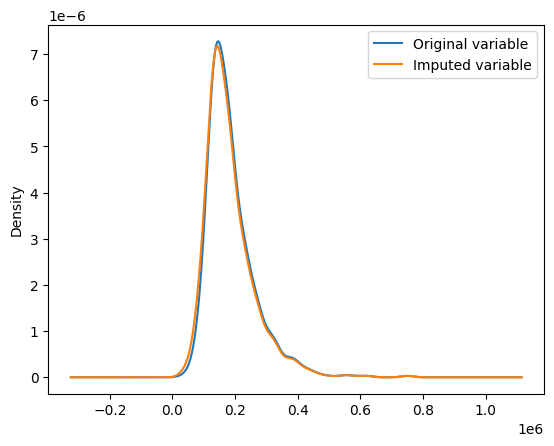

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp_df.plot(kind='kde', ax=ax)
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

ax.legend(['Original variable', 'Imputed variable'], loc='best')

<Axes: xlabel='FireplaceQu'>

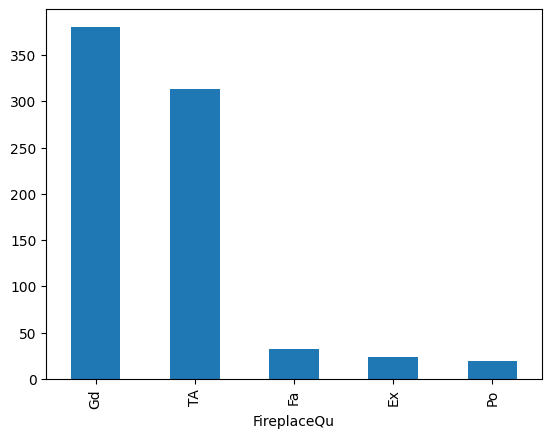

In [11]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()

In [12]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

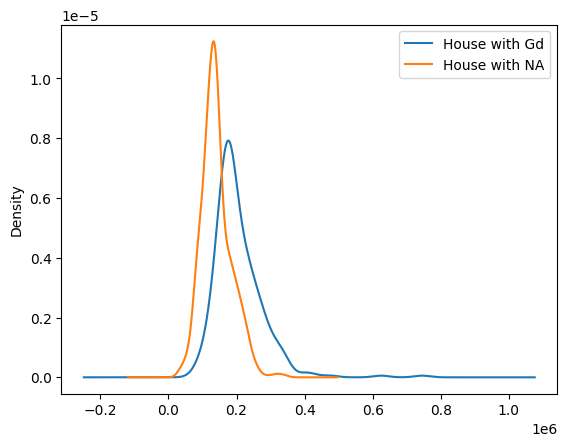

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

ax.legend(['House with Gd', 'House with NA'], loc='best')

In [14]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [15]:
df.fillna({'FireplaceQu': 'Gd'}, inplace=True)

<Axes: xlabel='FireplaceQu'>

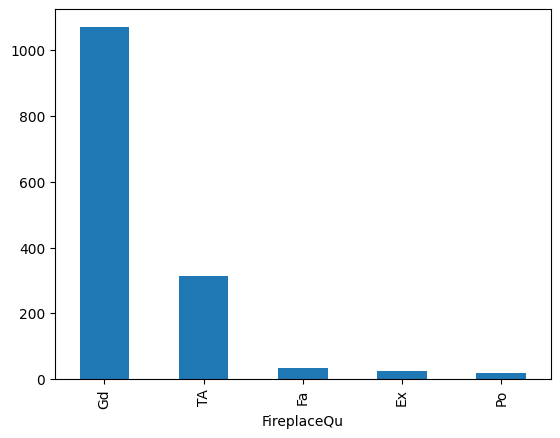

In [16]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()

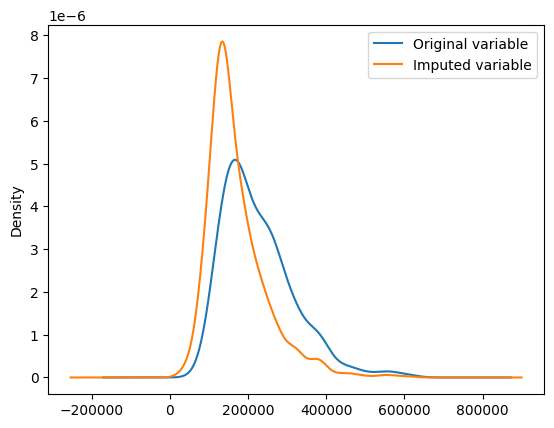

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)

ax.legend(['Original variable', 'Imputed variable'], loc='best')

### Using SKLearn:

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'],test_size=0.2)

In [19]:
imputer = SimpleImputer(strategy='most_frequent')

In [20]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_train)

In [21]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

**b. Missing as Its Own Category**

Instead of guessing a value, treat "missing" as a **valid category of its own** (e.g., replace NaN with the string `"Missing"`).

- Avoids making an assumption about what the true value might have been.
- Especially useful when missingness is **not random** — i.e., the fact that data is missing might itself be predictive (e.g., a survey field left blank might correlate with a certain type of respondent).

In [22]:
new_df = pd.read_csv('housing_dataset.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
new_df.sample(5)

,FireplaceQu,GarageQual,SalePrice
1068,Gd,TA,151400
650,NaN,TA,205950
315,Gd,TA,188500
375,NaN,NaN,61000
380,Gd,TA,127000


In [23]:
new_df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of Houses')

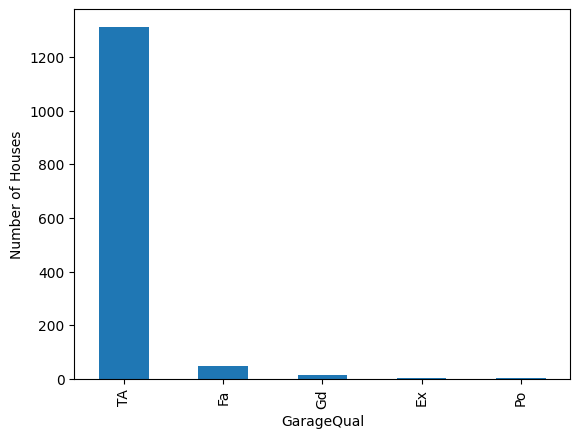

In [24]:
new_df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')

In [25]:
new_df['FireplaceQu'] = new_df['FireplaceQu'].fillna('Missing')

Text(0, 0.5, 'Number of Houses')

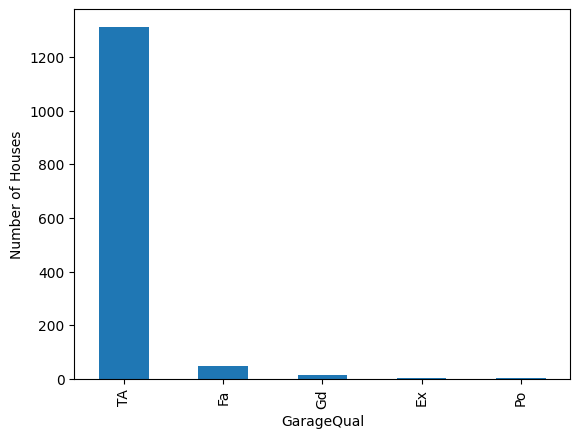

In [26]:
new_df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')

Text(0, 0.5, 'Number of Houses')

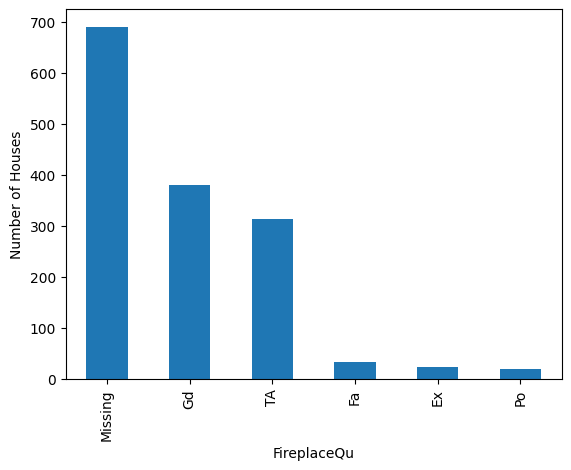

In [27]:
new_df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('FireplaceQu')
plt.ylabel('Number of Houses')

In [28]:
new_df.fillna({'FireplaceQu': 'Missing'}, inplace=True)

Text(0, 0.5, 'Number of Houses')

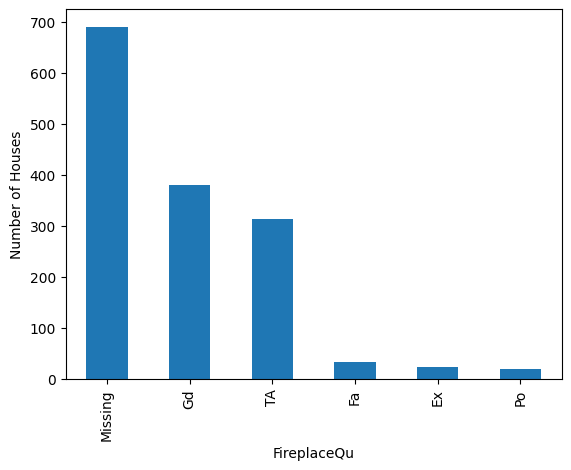

In [29]:
new_df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('FireplaceQu')
plt.ylabel('Number of Houses')

### Using SKLearn:

In [30]:
X_train, X_test, y_train, y_test = train_test_split(new_df.drop(columns=['SalePrice']), new_df['SalePrice'],test_size=0.2)

In [31]:
imputer = SimpleImputer(strategy='constant', fill_value='Missing')

In [32]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_train)

In [33]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)